In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_7_natural = get_prompt("natural", 7)

prompt_7_natural

'Simulate 1LYZ for 1ps at 300 K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute the RMSD, SASA, and radius of gyration of the simulation.'

In [3]:
llm_model = "gpt-4-turbo-2024-04-09"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_7_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: The task involves multiple steps: simulating the protein 1LYZ for 1 picosecond at 300 K, analyzing its secondary structure, computing RMSD, SASA, and radius of gyration, and reporting any known binding or active sites. First, I need to download the PDB structure of 1LYZ to proceed with the simulation setup.

Action:
```json
{
  "action": "PDBFileDownloader",
  "action_input": {
    "query": "1LYZ"
  }
}
```PDB file found with this ID: 1LYZ



Observation: Succeeded. Downloaded the PDB file:1LYZ_164811
Thought:

Now that I have the PDB file for 1LYZ, the next step is to set up and run the molecular dynamics simulation for 1 picosecond at 300 K. I will use the SetUpandRunFunction tool to perform this simulation.

Action:
```json
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_164811",
    "forcefield_files": ["amber14-all.xml", "amber14/tip3pfb.xml"],
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "HBonds",
      "rigidWater": true,
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 5
    }
  }
}
```Setting default ewaldErrorTolerance: 0.0005 
error found: constraintTolerance must be specified if rigidWater is True
 

To proceed with the simulation setup, I need to correct the system parameters by specifying the constraintTolerance since rigidWater is set to True. I will adjust the system parameters and rerun the simulation setup.

Action:
```json
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_164811",
    "forcefield_files": ["amber14-all.xml", "amber14/tip3pfb.xml"],
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": "0.00001",
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 5
    }
  }
}
```Setting default ewaldErrorTolerance: 0.0005 
Building system...


...

plot_name:  FIG_rgy_rec0_164857_20251223_174807.png
plot_path /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_37/figures/FIG_rgy_rec0_164857_20251223_174807.png

Observation: Succeeded. Radii of gyration saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_37/figures/radii_of_gyration_rec0_164857.csv with id rgy_rec0_164857.Plot saved as: FIG_rgy_rec0_164857_20251223_174807.png with plot ID fig0_174807Average radius of gyration: 3.45 nm
Thought:

The radius of gyration for the simulation of protein 1LYZ has been successfully computed. Now, I need to retrieve information about any known binding or active sites for 1LYZ to complete the analysis.

Action:
```json
{
  "action": "GetAllKnownSites",
  "action_input": {
    "query": "1LYZ",
    "primary_accession": ""
  }
}
```


Observation: Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]
No known binding sites.
No other relevant sites.
Thought:

The simulation of the protein 1LYZ for 1 picosecond at 300 K has been successfully completed, and the following analyses were conducted:

1. **Secondary Structure Analysis**:
   - Helix: 16,114 residues
   - Strand: 3,752 residues
   - Coil: 18,834 residues
   - Unassigned (not a protein residue): 2,039,700 residues

2. **Root Mean Square Deviation (RMSD)**:
   - The RMSD was calculated and the results were saved. A plot was also generated to visualize the RMSD over the simulation time.

3. **Solvent Accessible Surface Area (SASA)**:
   - SASA values were computed for the simulation trajectory, and the results were saved along with a plot for visualization.

4. **Radius of Gyration**:
   - The average radius of gyration was found to be 3.45 nm. The results and a plot were saved for further analysis.

5. **Known Sites**:
   - Active Sites: Two active sites were identified at residues 53 and 71, both supported by evidence from PROSITE-ProRule.
   - No known binding sites or other relevan

<Figure size 640x480 with 0 Axes>

In [3]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_164811: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_164811
 1LYZ_164839: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_164851: Initial positions for simulation sim0_164851
 sim0_164851: Basic Simulation of Protein 1LYZ_164839
 rec0_164857: Simulation trajectory for protein 1LYZ_164839 and simulation sim0_164851
 rec1_164857: Simulation state log for protein 1LYZ_164839 and simulation sim0_164851
 rec2_164857: Simulation pdb frames for protein 1LYZ_164839 and simulation sim0_164851
 rec0_170326: dssp values for trajectory with id: rec0_164857
 rmsd_164851: RMSD for 164851
 fig0_172253: RMSD plot for 164851
 sasa_sim0_164851: Total SASA values for sim0_164851
 fig0_174759: Plot of SASA over time for sim0_164851
 rgy_rec0_164857: Radii of gyration per frame for rec0_164857
 fig0_174807: Plot of radii of gyration over time fo

In [4]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_164811"))

In [5]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_164811", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [6]:
# make sure trajectory and topology exist
traj_path = registry.get_mapped_path("rec0_164857")
top_path = registry.get_mapped_path("top_sim0_164851")

assert os.path.exists(traj_path)
assert os.path.exists(top_path)

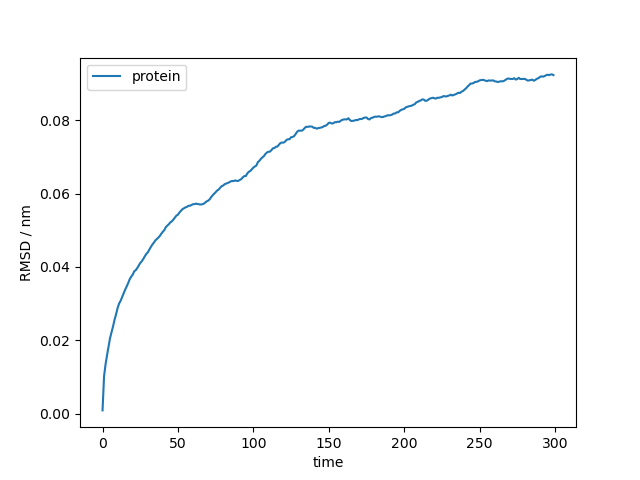

In [7]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_172253'))

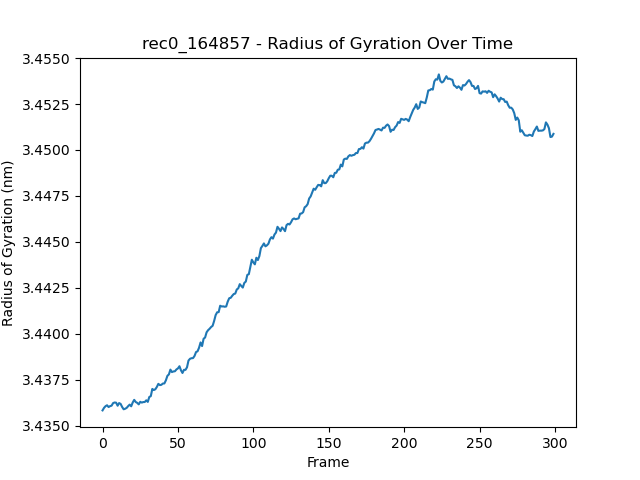

In [9]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_174807'))

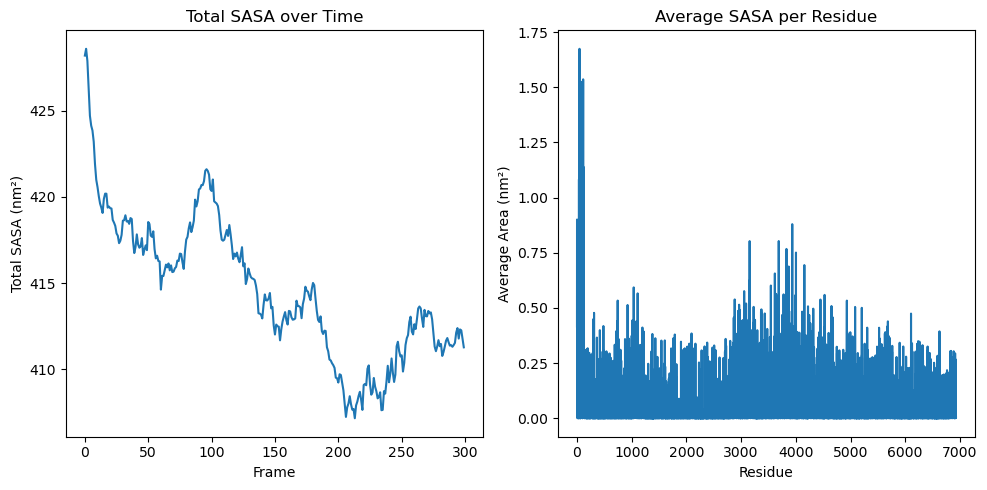

In [8]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_174759'))

In [14]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 99061
Output tokens: 1940
LLM costs: $ 1.04881
